# Results Dashboard

Benchmark results tables. Full analysis (charts, ablations) in `00a_results_analysis.ipynb`.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from notebook_utils import (
    ADMET_TASK_ORDER, TASK_CATEGORY, TASK_METRICS, TDC_SOTA,
    MINIMOL_GIT, MOLE, MOLGPS, KPGT, QIP, FAMILY_HATCHES,
    infer_model_name, infer_model_family, build_method_label,
    load_results, load_tdc_top10, count_best_among_methods, build_method_colors,
    load_probe_ensemble_dict, parse_pretrain_dataset,
)

# === Config: select which model(s) to show ===
MODELS_TO_SHOW = [
    'pairmixer_12M',
]

df, admet_df = load_results(models_to_show=MODELS_TO_SHOW)
print(f"Loaded {len(df)} rows, {len(admet_df)} ADMET rows")
print(f"Models: {sorted(df['model_name'].unique())}")
print(f"Methods: {sorted(admet_df['method'].unique())}")

# Method colors: consistent color per pre-training dataset
METHOD_COLORS = build_method_colors(admet_df)

# TDC top-10 leaderboard stats for z-score normalization
TDC_TOP10_ALL, TDC_TOP10_AVG, TDC_TOP10_MEDIAN = load_tdc_top10()


_STD_CELL_RE = re.compile(r'(-?\d+(?:\.\d+)?)\s*\xb1\s*(\d+(?:\.\d+)?)')

def _to_std_latex(_value):
    """Convert any 'mean \u00b1 std' substring to ``\\std{mean}{std}``.

    Pass-through for cells without \u00b1 (e.g. counts, '-', integer footers).
    Plays well with already-bolded cells: ``\\textbf{0.7 \u00b1 0.01}`` becomes
    ``\\textbf{\\std{0.7}{0.01}}``."""
    return _STD_CELL_RE.sub(r'\\std{\1}{\2}', str(_value))


def _to_clean_latex(_df, *, multirow=True, caption=None, resize_width=r'.9\columnwidth'):
    """Render a LaTeX table in the paper's house style: booktabs rules, outer index
    levels collapsed into a gray ``\\rowcolor{gray!12}\\multicolumn{...}{l}{\\textit{...}}``
    category header, the innermost index level as the row label, and metric column
    headers rendered as ``name ($\\uparrow$)`` / ``name ($\\downarrow$)``. Underscores
    and percent signs in headers/index labels are escaped for LaTeX; data values are
    written verbatim so existing ``\\textbf{...}`` markup is preserved.

    Requires ``\\usepackage[table]{xcolor}`` in the document preamble.
    The ``multirow`` kwarg is accepted for API compatibility but unused."""
    del multirow  # accepted for API compatibility

    def _latex_safe(_s, *, escape_underscore=True):
        _s = str(_s)
        if escape_underscore:
            _s = _s.replace('_', r'\_')
        for _u, _t in (
            ('%',  r'\%'),
            ('&',  r'\&'),
            ('#',  r'\#'),
            ('≤',  r'$\leq$'),
            ('≥',  r'$\geq$'),
            ('±',  r'$\pm$'),
            ('×',  r'$\times$'),
            ('→',  r'$\to$'),
        ):
            _s = _s.replace(_u, _t)
        return _s

    def _esc(_s):
        return _latex_safe(_s, escape_underscore=True)

    def _fmt_val(_v):
        if pd.isna(_v):
            return ''
        # Convert any 'mean \u00b1 std' to \std{}{} before escaping. Skip underscore
        # escape so pre-formatted LaTeX markup (e.g. \textbf{}) is preserved untouched.
        return _latex_safe(_to_std_latex(_v), escape_underscore=False)

    if isinstance(_df.index, pd.MultiIndex) and _df.index.nlevels > 1:
        _outer = [' / '.join(_esc(_x) for _x in _row[:-1]) for _row in _df.index]
        _inner = [_esc(_row[-1]) for _row in _df.index]
        _inner_name = _df.index.names[-1] or ''
    else:
        _outer = [None] * len(_df)
        _vals = (_df.index.get_level_values(0)
                 if isinstance(_df.index, pd.MultiIndex) else _df.index)
        _inner = [_esc(_v) for _v in _vals]
        _inner_name = ((_df.index.names[0] if isinstance(_df.index, pd.MultiIndex)
                        else _df.index.name) or '')

    _hdrs = []
    for _c in _df.columns:
        _s = str(_c)
        if '↑' in _s:
            _hdrs.append(f'{_esc(_s.replace("↑", "").strip())} ($\\uparrow$)')
        elif '↓' in _s:
            _hdrs.append(f'{_esc(_s.replace("↓", "").strip())} ($\\downarrow$)')
        else:
            _hdrs.append(_esc(_s))

    _ncols_total = 1 + len(_hdrs)
    _col_spec = 'l' + 'c' * len(_hdrs)

    _has_categories = any(_o is not None for _o in _outer)
    _out = [f'\\begin{{tabular}}{{{_col_spec}}}', '\\toprule']
    _out.append(' & '.join([_esc(_inner_name)] + _hdrs) + r' \\')
    if not _has_categories:
        _out.append('\\midrule')

    _prev_outer = None
    for _i, (_o, _inn) in enumerate(zip(_outer, _inner)):
        if _o is not None and _o != _prev_outer:
            _out.append('\\midrule')
            _out.append(
                f'\\rowcolor{{gray!12}}\\multicolumn{{{_ncols_total}}}{{l}}'
                f'{{\\textit{{{_o}}}}}' + r' \\'
            )
            _prev_outer = _o
        _row_vals = [_fmt_val(_df.iloc[_i, _j]) for _j in range(len(_df.columns))]
        _out.append(' & '.join([_inn] + _row_vals) + r' \\')

    _out.extend(['\\bottomrule', '\\end{tabular}'])
    _tabular = '\n'.join(_out)
    if caption is None:
        return _tabular
    _indented_tabular = '\n'.join('        ' + _ln for _ln in _tabular.split('\n'))
    return (
        '\\begin{table*}[!ht]\n'
        '    \\centering\n'
        f'    \\caption{{\\textbf{{{caption}}}}}\n'
        f'    \\resizebox{{{resize_width}}}{{!}}{{%\n'
        f'{_indented_tabular} %\n'
        '    }\n'
        '\\end{table*}'
    )


def _to_pivoted_main_metric_latex(_df, *, main_col, direction='higher', caption=None):
    """Simplified leaderboard view: rows = outer index levels (drop the innermost
    ``Model`` level), columns = model labels, cells = the single ``main_col`` metric.
    Bolds the best model per row, then formats via :func:`_to_clean_latex`."""
    _slim = _df[[main_col]].copy()
    _pivoted = _slim.unstack(level=-1)
    _pivoted.columns = _pivoted.columns.get_level_values(-1)
    _pivoted = _pivoted.astype(object)
    for _row_key in _pivoted.index:
        _vals = []
        for _col in _pivoted.columns:
            _raw = str(_pivoted.loc[_row_key, _col]).split(' ')[0]
            try:
                _vals.append((_col, float(_raw)))
            except ValueError:
                pass
        if len(_vals) < 2:
            continue
        _best_col = (max(_vals, key=lambda x: x[1])[0]
                     if direction == 'higher'
                     else min(_vals, key=lambda x: x[1])[0])
        _cur = _pivoted.loc[_row_key, _best_col]
        _pivoted.loc[_row_key, _best_col] = f'\\textbf{{{_cur}}}'
    _arrow = r'$\uparrow$' if direction == 'higher' else r'$\downarrow$'
    _metric_name = str(main_col).replace('↑', '').replace('↓', '').strip()
    if isinstance(_pivoted.index, pd.MultiIndex):
        _names = list(_pivoted.index.names)
        _names[-1] = f'{_names[-1] or ""} ({_metric_name} {_arrow})'.strip()
        _pivoted.index = _pivoted.index.set_names(_names)
    else:
        _pivoted.index.name = f'{_pivoted.index.name or ""} ({_metric_name} {_arrow})'.strip()
    return _to_clean_latex(_pivoted, caption=caption)

# Per-row pairmixer label: 'PairMixer 12M' (scratch) or 'PairMixer 12M (<dataset>)' (pretrained).
# Used by the Polaris ADME-Fang, GRAM-DTI, and Cell Bioactivity cells to differentiate
# pretrain recipes that share the same encoder='pairmixer' / model='pairmixer_12M' value.
_PAIRMIXER_PRETRAIN_RENAMES = {
    '4dset_ep99':         '4data_ep99',
    'toymix_dti_esmc_v2': 'toy_esmcv2',
}

def _pairmixer_pretty_label(ckpt_tag_or_path):
    s = str(ckpt_tag_or_path or '').lower()
    if not s or s in ('scratch', 'random', 'none', 'nan'):
        return 'PairMixer 12M'
    pretrain = parse_pretrain_dataset(s)
    if pretrain in ('scratch', 'unknown'):
        m = re.match(r'^last_(.+?)(?:_\d{4}-\d{2}-\d{2}.*)?$', s)
        pretrain = m.group(1) if m else s
    pretrain = _PAIRMIXER_PRETRAIN_RENAMES.get(pretrain, pretrain)
    return f'PairMixer 12M ({pretrain})'


Loaded 553 rows, 132 ADMET rows
Models: ['pairmixer_12M']
Methods: ['Scratch', 'toymix', 'toymix_bbbc047', 'toymix_dti_esmc_v2', 'toymix_dti_pactivity', 'toymix_lpm24']


/home/shpark/prj-molrepr/graphium/notebooks/notebook_utils.py:472: DtypeWarning: Columns (15,17,18,19,21,22,24,311) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


# Task 1 - ADMET

## TDC ADMET

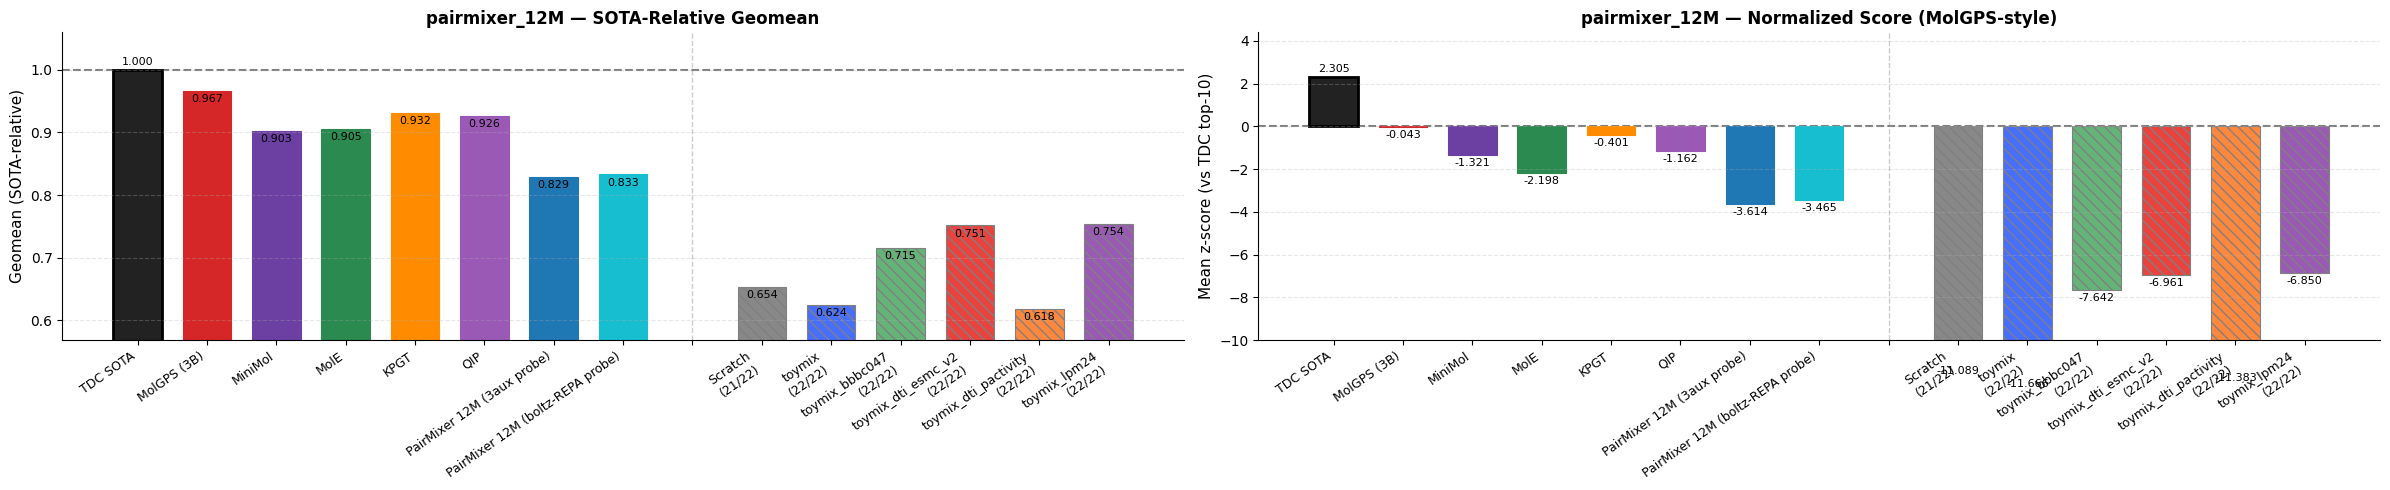


  Method                      Geomean   Z-score  Tasks
  ----------------------------------------------------
  TDC SOTA                     1.0000    2.3046     22
  MolGPS (3B)                  0.9670   -0.0434     22
  MiniMol                      0.9030   -1.3208     22
  MolE                         0.9051   -2.1982     22
  KPGT                         0.9316   -0.4014     22
  QIP                          0.9258   -1.1624     22
  PairMixer 12M (3aux probe)    0.8289   -3.6137     22
  PairMixer 12M (boltz-REPA probe)    0.8329   -3.4650     22

  Scratch                      0.6536  -11.0890     21
  toymix                       0.6239  -11.6661     22
  toymix_bbbc047               0.7150   -7.6423     22
  toymix_dti_esmc_v2           0.7514   -6.9608     22
  toymix_dti_pactivity         0.6178  -11.3829     22
  toymix_lpm24                 0.7539   -6.8495     22



In [2]:
# Two aggregate metrics across 22 ADMET tasks:
#
# 1. SOTA-relative geomean: value/SOTA (higher-better) or SOTA/value (lower-better),
#    then geometric mean. SOTA = 1.0 by construction.
#
# 2. MolGPS-style normalized score: z-score each task relative to the TDC top-10
#    leaderboard, flip sign for lower-is-better, then arithmetic mean.
#    Positive = above leaderboard average, negative = below.

def _sota_normalize(value, task):
    """Normalize a single value relative to TDC SOTA for that task."""
    if task not in TDC_SOTA or pd.isna(value):
        return np.nan
    sota_mean = TDC_SOTA[task][0]
    direction = TASK_METRICS[task][1]
    if sota_mean == 0:
        return np.nan
    if direction == 'higher':
        return value / sota_mean
    else:
        return sota_mean / value if value != 0 else np.nan

def _zscore_normalize(value, task):
    """Z-score relative to TDC top-10 leaderboard, sign-flipped for lower-is-better."""
    if task not in TDC_TOP10_AVG or pd.isna(value):
        return np.nan
    lb_mean, lb_std = TDC_TOP10_AVG[task]
    if lb_std < 1e-12:
        return 0.0
    direction = TASK_METRICS[task][1]
    z = (value - lb_mean) / lb_std
    return z if direction == 'higher' else -z

def _geomean(values):
    """Geometric mean of positive values, ignoring NaN."""
    v = [x for x in values if np.isfinite(x) and x > 0]
    if not v:
        return np.nan
    return np.exp(np.mean(np.log(v)))

def _mean_zscore(values):
    """Arithmetic mean of z-scores, ignoring NaN."""
    v = [x for x in values if np.isfinite(x)]
    if not v:
        return np.nan
    return np.mean(v)

# --- External baselines: (display_label, data_dict, bar_color) ---
_BASELINES = [
    ('TDC SOTA',     {t: (TDC_SOTA[t][0],) for t in ADMET_TASK_ORDER if t in TDC_SOTA}, '#222222'),
    ('MolGPS (3B)',  MOLGPS,       '#d62728'),
    ('MiniMol',      MINIMOL_GIT,  '#6c3fa3'),
    ('MolE',         MOLE,         '#2a8a4f'),
    ('KPGT',         KPGT,         '#FF8C00'),
    ('QIP',          QIP,          '#9b59b6'),
    ('PairMixer 12M (3aux probe)',
     load_probe_ensemble_dict('toymix-3aux-combined', model='pairmixer_12M'),
     '#1f77b4'),
    ('PairMixer 12M (boltz-REPA probe)',
     load_probe_ensemble_dict('toymix-boltz-repa', model='pairmixer_12M'),
     '#17becf'),
]

_baseline_geomeans = {}
_baseline_zscores = {}
for _bname, _bdata, _ in _BASELINES:
    _gn = [_sota_normalize(_bdata[t][0], t) for t in ADMET_TASK_ORDER if t in _bdata]
    _zn = [_zscore_normalize(_bdata[t][0], t) for t in ADMET_TASK_ORDER if t in _bdata]
    _baseline_geomeans[_bname] = _geomean(_gn)
    _baseline_zscores[_bname] = _mean_zscore(_zn)

# --- Compute per (model, method) from our runs ---
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    _task_method_means = admet_df.groupby(['task', 'model_name', 'method'])['primary_metric'].mean()

    _all_geomeans = list(_baseline_geomeans.values())
    _all_zscores = list(_baseline_zscores.values())
    _model_data = {}

    for model_name in MODELS_TO_SHOW:
        model_df = admet_df[admet_df['model_name'] == model_name]
        if len(model_df) == 0:
            continue
        methods = sorted(model_df['method'].unique(), key=lambda m: (0 if m == 'Scratch' else 1, m))
        _method_geomeans = {}
        _method_zscores = {}
        _method_ntasks = {}
        for method in methods:
            _gn, _zn = [], []
            for task in ADMET_TASK_ORDER:
                try:
                    val = _task_method_means.loc[(task, model_name, method)]
                    _gn.append(_sota_normalize(val, task))
                    _zn.append(_zscore_normalize(val, task))
                except KeyError:
                    pass
            _method_geomeans[method] = _geomean(_gn)
            _method_zscores[method] = _mean_zscore(_zn)
            _method_ntasks[method] = sum(1 for x in _gn if np.isfinite(x) and x > 0)
            if np.isfinite(_method_geomeans[method]):
                _all_geomeans.append(_method_geomeans[method])
            if np.isfinite(_method_zscores[method]):
                _all_zscores.append(_method_zscores[method])
        _model_data[model_name] = (methods, _method_geomeans, _method_zscores, _method_ntasks)

    # Shared y-axis ranges
    _gm_finite = [v for v in _all_geomeans if np.isfinite(v)]
    _gm_ymin = min(_gm_finite) * 0.92 if _gm_finite else 0
    _gm_ymax = max(_gm_finite) * 1.06 if _gm_finite else 1
    _zs_finite = [v for v in _all_zscores if np.isfinite(v)]
    _zs_pad = (max(_zs_finite) - min(_zs_finite)) * 0.15 if _zs_finite else 1
    _zs_ymin = max(min(_zs_finite) - _zs_pad, -10) if _zs_finite else -1
    _zs_ymax = max(_zs_finite) + _zs_pad if _zs_finite else 1

    baseline_colors = {name: color for name, _, color in _BASELINES}

    for model_name in MODELS_TO_SHOW:
        # Only the pairmixer_12M plot shows the PairMixer 12M (3aux probe) bar,
        # since that probe checkpoint is specific to that model.
        baseline_names = [name for name, _, _ in _BASELINES
                          if not (name.startswith('PairMixer 12M')
                                  and model_name != 'pairmixer_12M')]
        if model_name not in _model_data:
            continue
        methods, _mg, _mz, _mnt = _model_data[model_name]
        family = infer_model_family(model_name)
        hatch = FAMILY_HATCHES.get(family, '')

        all_labels = baseline_names + [''] + methods
        gm_vals = [_baseline_geomeans[b] for b in baseline_names] + [np.nan] + [_mg[m] for m in methods]
        zs_vals = [_baseline_zscores[b] for b in baseline_names] + [np.nan] + [_mz[m] for m in methods]
        n = len(all_labels)
        x = np.arange(n)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(max(18, n * 1.6), 5))

        for ax, vals, ylabel, title_suffix, ymin, ymax, refline in [
            (ax1, gm_vals, 'Geomean (SOTA-relative)', 'SOTA-Relative Geomean', _gm_ymin, _gm_ymax, 1.0),
            (ax2, zs_vals, 'Mean z-score (vs TDC top-10)', 'Normalized Score (MolGPS-style)', _zs_ymin, _zs_ymax, 0.0),
        ]:
            for i, (label, val) in enumerate(zip(all_labels, vals)):
                if label == '' or pd.isna(val):
                    continue
                if label in baseline_colors:
                    color = baseline_colors[label]
                    h = ''
                    ec = 'black' if label == 'TDC SOTA' else color
                    lw = 2.0 if label == 'TDC SOTA' else 0.8
                else:
                    color = METHOD_COLORS.get(label, '#466eff')
                    h = hatch
                    ec = 'grey' if h else color
                    lw = 0.8
                ax.bar(i, val, color=color, hatch=h, edgecolor=ec, linewidth=lw, width=0.7)
                offset = (ymax - ymin) * 0.01
                va = 'bottom' if val >= refline else 'top'
                ax.text(i, val + (offset if va == 'bottom' else -offset),
                        f'{val:.3f}', ha='center', va=va, fontsize=8)

            ax.axhline(y=refline, color='black', linewidth=1.5, linestyle='--', alpha=0.5, zorder=0)
            sep_x = len(baseline_names)
            ax.axvline(x=sep_x - 0.5 + 0.5, color='grey', linewidth=1, linestyle='--', alpha=0.4)
            ax.set_xticks(x)
            _xlabels = []
            for label in all_labels:
                if label == '' or label in baseline_colors:
                    _xlabels.append(label)
                else:
                    _nt = _mnt.get(label, 0)
                    _xlabels.append(f'{label}\n({_nt}/{len(ADMET_TASK_ORDER)})')
            ax.set_xticklabels(_xlabels, rotation=35, ha='right', fontsize=9)
            ax.set_ylabel(ylabel, fontsize=11)
            ax.set_title(f'{model_name} — {title_suffix}', fontsize=12, fontweight='bold')
            ax.set_ylim(ymin, ymax)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.grid(True, axis='y', ls='--', alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Print table
        print(f"\n{'':2s}{'Method':25s}  {'Geomean':>8s}  {'Z-score':>8s}  {'Tasks':>5s}")
        print("  " + "-" * 52)
        for b in baseline_names:
            print(f"  {b:25s}  {_baseline_geomeans[b]:>8.4f}  {_baseline_zscores[b]:>8.4f}  {22:>5d}")
        print()
        for m in methods:
            print(f"  {m:25s}  {_mg[m]:>8.4f}  {_mz[m]:>8.4f}  {_mnt[m]:>5d}")
        print()
else:
    print("No ADMET results to plot.")

In [3]:
print(f"ADMET results: {len(admet_df)} rows")
print(f"Methods: {sorted(admet_df['method'].unique())}")

# --- Display one table per architecture ---
if len(admet_df) > 0 and admet_df['primary_metric'].notna().any():
    for model_name in MODELS_TO_SHOW:
        model_df = admet_df[admet_df['model_name'] == model_name]

        if len(model_df) == 0 or model_df['primary_metric'].isna().all():
            # No data at all — show empty table with all tasks
            pivot = pd.DataFrame(index=ADMET_TASK_ORDER, columns=['(no results)'])
            pivot['(no results)'] = np.nan
        else:
            pivot = model_df.pivot_table(
                index='task', columns='method', values='primary_metric', aggfunc='mean'
            )
            method_order = ['Scratch'] + sorted([c for c in pivot.columns if c != 'Scratch'])
            method_order += [c for c in pivot.columns if c not in method_order]
            pivot = pivot[[c for c in method_order if c in pivot.columns]]

            # Inject the MiniMol-style probe-ensemble result for the 3aux pre-trained
            # checkpoint (only available for pairmixer_12M).
            if model_name == 'pairmixer_12M':
                _3aux_probe = load_probe_ensemble_dict(
                    'toymix-3aux-combined', model='pairmixer_12M'
                )
                if _3aux_probe:
                    pivot['toymix_3aux (probe)'] = pd.Series(
                        {t: m for t, (m, _s) in _3aux_probe.items()}
                    )

        # Reindex to always show all 22 ADMET tasks (NaN for missing)
        pivot = pivot.reindex(ADMET_TASK_ORDER)

        row_labels = []
        for task in pivot.index:
            metric_name, direction = TASK_METRICS.get(task, ('?', 'higher'))
            arrow = '↑' if direction == 'higher' else '↓'
            row_labels.append(f'{task}  ({metric_name} {arrow})')

        # Find best column per row within this architecture
        arch_best_per_row = {}
        for task in pivot.index:
            direction = TASK_METRICS.get(task, (None, 'higher'))[1]
            row_vals = pivot.loc[task].dropna()
            if len(row_vals) > 0:
                best_col = row_vals.idxmin() if direction == 'lower' else row_vals.idxmax()
                arch_best_per_row[task] = best_col

        numeric_pivot = pivot.copy()

        # Insert TDC SOTA column on the left
        sota_col = []
        for task in pivot.index:
            if task in TDC_SOTA:
                mean, std, _ = TDC_SOTA[task]
                sota_col.append(f'{mean:.3f} ± {std:.3f}')
            else:
                sota_col.append('')
        pivot.insert(0, 'TDC SOTA', sota_col)

        # Compute category boundaries
        category_boundaries = set()
        prev_cat = None
        for i, task in enumerate(pivot.index):
            cat = TASK_CATEGORY.get(task)
            if prev_cat is not None and cat != prev_cat:
                category_boundaries.add(i)
            prev_cat = cat

        display_pivot = pivot.copy()
        display_pivot.index = row_labels

        # Styling: one highlight per row — best within this architecture is bold
        # + underlined; colored red if it is at or above SOTA (within 1 std).
        def make_highlight(arch_best, dp, pv):
            def highlight(row):
                task = pv.index[dp.index.get_loc(row.name)]
                styles = [''] * len(row)
                if task not in arch_best:
                    return styles
                cols = list(dp.columns)
                best_col = arch_best[task]
                if best_col not in cols:
                    return styles
                j = cols.index(best_col)
                try:
                    best_val = float(row.iloc[j])
                except (ValueError, TypeError):
                    return styles
                if pd.isna(best_val):
                    return styles

                direction = TASK_METRICS.get(task, (None, None))[1]
                sota_info = TDC_SOTA.get(task)
                near_sota = False
                if sota_info is not None and direction is not None:
                    sota_mean, sota_std, _ = sota_info
                    if direction == 'higher' and best_val >= sota_mean - sota_std:
                        near_sota = True
                    elif direction == 'lower' and best_val <= sota_mean + sota_std:
                        near_sota = True

                base = 'font-weight: bold; text-decoration: underline'
                styles[j] = f'{base}; color: #cc0000' if near_sota else base
                return styles
            return highlight

        def make_category_borders(boundaries, dp):
            def category_borders(row):
                idx = dp.index.get_loc(row.name)
                if idx in boundaries:
                    return ['border-top: 3px solid black'] * len(row)
                return [''] * len(row)
            return category_borders

        def sota_style(col):
            if col.name == 'TDC SOTA':
                return ['background-color: #f0f0f0; color: #555; font-size: 0.9em'] * len(col)
            return [''] * len(col)

        styled = (
            display_pivot.style
            .format(precision=4, na_rep='',
                    subset=[c for c in display_pivot.columns if c != 'TDC SOTA'])
            .apply(make_highlight(arch_best_per_row, display_pivot, pivot), axis=1)
            .apply(make_category_borders(category_boundaries, display_pivot), axis=1)
            .apply(sota_style, axis=0)
            .set_caption(f'{model_name} — ADMET Performance (TDC SOTA on left for reference)')
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold')]},
                {'selector': 'td', 'props': [('text-align', 'center')]},
            ])
        )

        print(f"\n{'='*60}")
        print(f"  {model_name}")
        print(f"{'='*60}")
        print("Bold + underline = best per row | Red = at or above TDC SOTA (within 1 std)")
        display(styled)

        # Count tasks where each method is the best
        best_counts = count_best_among_methods(numeric_pivot, list(numeric_pivot.columns), TASK_METRICS)
        if best_counts:
            print(f"\nTasks where each method is best ({model_name}):")
            for method, (wins, total) in best_counts.items():
                print(f"  {method}: {wins}/{total}")

    # --- Cross-architecture summary ---
    combined_pivot = admet_df.pivot_table(
        index='task', columns=['model_name', 'method'],
        values='primary_metric', aggfunc='mean'
    )
    combined_pivot = combined_pivot.loc[[t for t in ADMET_TASK_ORDER if t in combined_pivot.index]]
    all_cols = list(combined_pivot.columns)
    best_counts = count_best_among_methods(combined_pivot, all_cols, TASK_METRICS)

    print(f"\n{'='*60}")
    print("  Cross-architecture summary: tasks where each (model, method) is best")
    print(f"{'='*60}")
    for col, (wins, total) in best_counts.items():
        model, method = col
        print(f"  {model} / {method}: {wins}/{total}")
else:
    print("No ADMET results found yet. Run experiments first.")


ADMET results: 132 rows
Methods: ['Scratch', 'toymix', 'toymix_bbbc047', 'toymix_dti_esmc_v2', 'toymix_dti_pactivity', 'toymix_lpm24']

  pairmixer_12M
Bold + underline = best per row | Red = at or above TDC SOTA (within 1 std)


method,TDC SOTA,Scratch,toymix,toymix_bbbc047,toymix_dti_esmc_v2,toymix_dti_pactivity,toymix_lpm24,toymix_3aux (probe)
caco2_wang (mae ↓),0.256 ± 0.006,0.6367,0.8164,0.5547,0.5234,0.8711,0.5352,0.4087
hia_hou (auroc ↑),0.993 ± 0.005,0.8521,0.9374,0.9652,0.9492,0.9323,0.9165,0.9886
pgp_broccatelli (auroc ↑),0.948 ± 0.000,0.8738,0.9020,0.9029,0.8924,0.8932,0.8732,0.9311
bioavailability_ma (auroc ↑),0.938 ± 0.002,0.5737,0.5883,0.7281,0.6147,0.6018,0.6142,0.6067
lipophilicity_astrazeneca (mae ↓),0.386 ± 0.000,0.5625,0.9375,0.8828,0.8242,0.9062,0.8398,0.5218
solubility_aqsoldb (mae ↓),0.679 ± 0.000,0.7930,1.1797,1.0938,1.0156,1.1562,1.0938,0.7962
bbb_martins (auroc ↑),0.941 ± 0.000,0.8937,0.7690,0.8040,0.8668,0.7849,0.8952,0.8882
ppbr_az (mae ↓),6.464 ± 0.000,26.1250,11.6875,8.4375,8.5625,10.7500,8.5625,9.0961
vdss_lombardo (spearman ↑),0.713 ± 0.007,0.5820,0.4766,0.5664,0.5703,0.4395,0.5312,0.4595
cyp2d6_veith (auprc ↑),0.790 ± 0.001,0.5371,0.4979,0.4946,0.6188,0.4806,0.5830,0.6743



Tasks where each method is best (pairmixer_12M):
  Scratch: 2/22
  toymix: 0/22
  toymix_bbbc047: 3/22
  toymix_dti_esmc_v2: 1/22
  toymix_dti_pactivity: 0/22
  toymix_lpm24: 3/22
  toymix_3aux (probe): 13/22

  Cross-architecture summary: tasks where each (model, method) is best
  pairmixer_12M / Scratch: 6/22
  pairmixer_12M / toymix: 0/22
  pairmixer_12M / toymix_bbbc047: 5/22
  pairmixer_12M / toymix_dti_esmc_v2: 5/22
  pairmixer_12M / toymix_dti_pactivity: 0/22
  pairmixer_12M / toymix_lpm24: 6/22


In [4]:
# Paper LaTeX table for TDC ADMET on PairMixer 12M.
# - Cells: \std{mean}{std} with 3 decimal places
# - Per-column \phantom{0}/\phantom{-} alignment so wide / negative entries don't
#   throw off narrower siblings
# - Best per row across the seven baseline columns is wrapped in \textbf{...}

_MODEL_NAME = 'pairmixer_12M'
_SCRATCH_METHOD = 'Scratch'

# Pretrained-variant columns: (method_in_admet_df, short_label_for_header)
# `toymix_3aux` is a placeholder — when the multi-aux pretrain run is added to
# experiment_results.csv it will populate this column automatically.
_PRETRAINED_COLUMNS = [
    ('toymix_dti_esmc_v2', 'esmc'),
    ('toymix_lpm24',       'lit-openai'),
    ('toymix_3aux',        '3aux'),
]

_TABLE_TASK_ORDER = [
    'caco2_wang', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma',
    'lipophilicity_astrazeneca', 'solubility_aqsoldb',
    'bbb_martins', 'ppbr_az', 'vdss_lombardo',
    'cyp2c9_veith', 'cyp2d6_veith', 'cyp3a4_veith',
    'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels',
    'cyp3a4_substrate_carbonmangels',
    'half_life_obach', 'clearance_hepatocyte_az', 'clearance_microsome_az',
    'ld50_zhu', 'herg', 'ames', 'dili',
]
_TABLE_TASK_LABELS = {
    'caco2_wang': 'Caco2', 'hia_hou': 'HIA', 'pgp_broccatelli': 'Pgp',
    'bioavailability_ma': 'Bioavailability', 'lipophilicity_astrazeneca': 'Lipophilicity',
    'solubility_aqsoldb': 'Solubility',
    'bbb_martins': 'BBB', 'ppbr_az': 'PPBR', 'vdss_lombardo': 'VDss',
    'cyp2c9_veith': r'CYP2C9 V.\ ', 'cyp2d6_veith': r'CYP2D6 V.\ ',
    'cyp3a4_veith': r'CYP3A4 V.\ ',
    'cyp2c9_substrate_carbonmangels': r'CYP2C9 S.\ ',
    'cyp2d6_substrate_carbonmangels': r'CYP2D6 S.\ ',
    'cyp3a4_substrate_carbonmangels': r'CYP3A4 S.\ ',
    'half_life_obach': 'Half Life',
    'clearance_hepatocyte_az': r'Clearance H.\ ',
    'clearance_microsome_az': r'Clearance M.\ ',
    'ld50_zhu': 'LD50', 'herg': 'hERG', 'ames': 'AMES', 'dili': 'DILI',
}
_TABLE_CATEGORIES = [
    ('Absorption', ['caco2_wang', 'hia_hou', 'pgp_broccatelli', 'bioavailability_ma',
                    'lipophilicity_astrazeneca', 'solubility_aqsoldb']),
    ('Distribution', ['bbb_martins', 'ppbr_az', 'vdss_lombardo']),
    ('Metabolism', ['cyp2c9_veith', 'cyp2d6_veith', 'cyp3a4_veith',
                    'cyp2c9_substrate_carbonmangels', 'cyp2d6_substrate_carbonmangels',
                    'cyp3a4_substrate_carbonmangels']),
    ('Excretion', ['half_life_obach', 'clearance_hepatocyte_az', 'clearance_microsome_az']),
    ('Toxicity', ['ld50_zhu', 'herg', 'ames', 'dili']),
]


def _ours_per_task_stats(full_df, model_name, method):
    sub = full_df[(full_df['model_name'] == model_name) & (full_df['method'] == method)]
    if sub.empty:
        return {}
    out = {}
    for t in _TABLE_TASK_ORDER:
        rows = sub[sub['task'] == t].dropna(subset=['primary_metric'])
        if rows.empty:
            continue
        per_seed = rows.groupby('seed')['primary_metric'].mean().dropna()
        if per_seed.empty:
            continue
        m = float(per_seed.mean())
        s = float(per_seed.std(ddof=1)) if len(per_seed) > 1 else 0.0
        out[t] = (m, s)
    return out


def _column_widths(src):
    """Per-column padding metadata: (max_int_mean, max_int_std, has_negative)."""
    max_im, max_is, has_neg = 1, 1, False
    for t in _TABLE_TASK_ORDER:
        pair = src.get(t)
        if pair is None:
            continue
        m, s = pair
        if m < 0:
            has_neg = True
        max_im = max(max_im, len(f'{abs(m):.0f}'))
        max_is = max(max_is, len(f'{abs(s):.0f}'))
    return max_im, max_is, has_neg


def _fmt_cell(pair, max_im, max_is, has_neg, n_dec=3):
    """Format \std{m}{s} with \phantom{0}/\phantom{-} so column widths match."""
    if pair is None:
        m_pad = r'\phantom{0}' * max(0, max_im - 1)
        s_pad = r'\phantom{0}' * max(0, max_is - 1)
        sign = r'\phantom{-}' if has_neg else ''
        return f'\\std{{{sign}{m_pad}X.{"X"*n_dec}}}{{{s_pad}x.{"x"*n_dec}}}'
    m, s = pair
    m_int_w = len(f'{abs(m):.0f}')
    s_int_w = len(f'{abs(s):.0f}')
    m_zpad = r'\phantom{0}' * max(0, max_im - m_int_w)
    s_zpad = r'\phantom{0}' * max(0, max_is - s_int_w)
    if has_neg:
        sign = '-' if m < 0 else r'\phantom{-}'
        mean_field = f'{sign}{m_zpad}{abs(m):.{n_dec}f}'
    else:
        mean_field = f'{m_zpad}{abs(m):.{n_dec}f}' if m >= 0 else f'-{m_zpad}{abs(m):.{n_dec}f}'
    std_field = f'{s_zpad}{abs(s):.{n_dec}f}'
    return f'\\std{{{mean_field}}}{{{std_field}}}'


def print_pairmixer12m_paper_table():
    """Emit the LaTeX paper table for TDC ADMET on PairMixer 12M."""
    full_df, _ = load_results(models_to_show=[_MODEL_NAME])
    full_df = full_df[full_df['data_fraction'] >= 1.0]

    sota_pairs    = {t: (TDC_SOTA[t][0], TDC_SOTA[t][1]) for t in _TABLE_TASK_ORDER if t in TDC_SOTA}
    mole_pairs    = {t: (MOLE[t][0], MOLE[t][1])        for t in _TABLE_TASK_ORDER if t in MOLE}
    minimol_pairs = {t: (MINIMOL_GIT[t][0], MINIMOL_GIT[t][1]) for t in _TABLE_TASK_ORDER if t in MINIMOL_GIT}
    molgps_pairs  = {t: (MOLGPS[t][0], MOLGPS[t][1])    for t in _TABLE_TASK_ORDER if t in MOLGPS}
    kpgt_pairs    = {t: (KPGT[t][0], KPGT[t][1])        for t in _TABLE_TASK_ORDER if t in KPGT}
    qip_pairs     = {t: (QIP[t][0], QIP[t][1])         for t in _TABLE_TASK_ORDER if t in QIP}
    scratch_pairs = _ours_per_task_stats(full_df, _MODEL_NAME, _SCRATCH_METHOD)

    pretrained_data = []
    for method, label in _PRETRAINED_COLUMNS:
        if method == 'toymix_3aux':
            pairs = load_probe_ensemble_dict('toymix-3aux-combined', model=_MODEL_NAME)
        else:
            pairs = _ours_per_task_stats(full_df, _MODEL_NAME, method)
        pretrained_data.append((label, pairs))

    columns = [
        ('SOTA',          sota_pairs,    '-',       '-'),
        ('Scratch',       scratch_pairs, r'\xmark', r'\xmark'),
        ('MolE',          mole_pairs,    r'\cmark', r'\xmark'),
        ('KPGT',          kpgt_pairs,    r'\cmark', r'\xmark'),
        ('QIP',           qip_pairs,     r'\cmark', r'\xmark'),
        ('MiniMol',       minimol_pairs, r'\cmark', r'\cmark'),
        ('MolGPS (3B)',   molgps_pairs,  r'\cmark', r'\cmark'),
    ]
    for label, pairs in pretrained_data:
        columns.append((label, pairs, r'\cmark', r'\cmark'))

    col_meta = [_column_widths(src) for _name, src, _pt, _en in columns]

    n_method_cols = len(columns)
    n_total_cols = 1 + n_method_cols
    arrows = {'higher': r'$\uparrow$', 'lower': r'$\downarrow$'}

    out = []
    out.append(r'\begin{table}[!ht]')
    out.append(r'    \centering')
    out.append(r'    \caption{')
    out.append(r'        \textbf{Results on ADMET property prediction benchmark.}')
    out.append(r'        $^{\dagger}$SOTA denotes the highest score reported on the TDC ADMET benchmark leaderboards as of March 2026, excluding the baselines in the table. V., S., H., and M.\ each denote Veith, Substrate, Hepatocyte, and Microsome, respectively. Results are averaged over five random seeds, where {Bold} indicates the best performance.')
    out.append(r'    }')
    out.append(r'    \resizebox{\textwidth}{!}{ %')
    col_spec = 'lc|' + 'c' * (n_method_cols - 1)
    out.append(f'        \\begin{{tabular}}{{{col_spec}}}')
    out.append(r'            \toprule')
    header_cells = [r'\textbf{Model}', r'$^{\dagger}$SOTA', r'\textbf{\method}',
                    'MolE', 'KPGT', 'QIP', 'MiniMol', 'MolGPS (3B)']
    for _method, label in _PRETRAINED_COLUMNS:
        header_cells.append(f'\\textbf{{\\method ({label})}}')
    out.append('            ' + ' & '.join(header_cells) + r' \\')
    out.append(r'            \midrule')
    out.append('            Pre-training & ' + ' & '.join(c[2] for c in columns) + r' \\')
    out.append('            Ensemble     & ' + ' & '.join(c[3] for c in columns) + r' \\')
    out.append(r'            \midrule')
    out.append(r'            \midrule')

    geomeans = {name: [] for name, *_ in columns}
    n_first  = {name: 0  for name, *_ in columns}
    n_second = {name: 0  for name, *_ in columns}

    for ci, (cat_name, cat_tasks) in enumerate(_TABLE_CATEGORIES):
        if ci > 0:
            out.append(r'            \midrule')
        out.append(f'            \\rowcolor{{gray!12}}\\multicolumn{{{n_total_cols}}}{{l}}'
                   f'{{\\textit{{{cat_name}}}}} \\\\')
        for task in cat_tasks:
            metric_name, direction = TASK_METRICS[task]
            arrow = arrows[direction]

            vals = []
            for name, src, _pt, _en in columns:
                pair = src.get(task)
                vals.append(pair[0] if pair is not None else None)

            ranked = [(i, v) for i, v in enumerate(vals) if v is not None and i != 0]
            if ranked:
                ranked.sort(key=lambda x: x[1], reverse=(direction == 'higher'))
                best_idx = ranked[0][0]
                second_idx = ranked[1][0] if len(ranked) > 1 else -1
                n_first[columns[best_idx][0]] += 1
                if second_idx >= 0:
                    n_second[columns[second_idx][0]] += 1
            else:
                best_idx = -1

            cells = []
            for i, (name, src, _pt, _en) in enumerate(columns):
                pair = src.get(task)
                max_im, max_is, has_neg = col_meta[i]
                txt = _fmt_cell(pair, max_im, max_is, has_neg)
                if i == best_idx and pair is not None:
                    txt = f'\\textbf{{{txt}}}'
                cells.append(txt)

            label = _TABLE_TASK_LABELS[task] + arrow
            out.append('            ' + label + ' & ' + ' & '.join(cells) + r' \\')

            sota_pair = sota_pairs.get(task)
            if sota_pair is not None and sota_pair[0] != 0:
                for name, src, _pt, _en in columns:
                    pair = src.get(task)
                    if pair is None:
                        continue
                    if direction == 'higher':
                        ratio = pair[0] / sota_pair[0]
                    else:
                        ratio = sota_pair[0] / pair[0] if pair[0] > 0 else None
                    if ratio is not None and ratio > 0:
                        geomeans[name].append(ratio)

    out.append(r'            \midrule')
    out.append(r'            \midrule')
    out.append(f'            \\rowcolor{{gray!12}}\\multicolumn{{{n_total_cols}}}{{l}}'
               r'{\textit{Overall performance}} \\')

    def _gm(vs):
        vs = [v for v in vs if v is not None and v > 0]
        return float(np.exp(np.mean(np.log(vs)))) if vs else None

    gm_cells, n1_cells, n2_cells = [], [], []
    for name, *_ in columns:
        gm = _gm(geomeans[name])
        gm_cells.append('-' if gm is None else f'{gm:.3f}')
        if name == 'SOTA':
            n1_cells.append('-')
            n2_cells.append('-')
        else:
            n1_cells.append(str(n_first[name]))
            n2_cells.append(str(n_second[name]))

    out.append(r'            \multicolumn{1}{l}{Geometric mean} & ' + ' & '.join(gm_cells) + r' \\')
    out.append(r'            \multicolumn{1}{l}{\# of 1st}        & ' + ' & '.join(n1_cells) + r' \\')
    out.append(r'            \multicolumn{1}{l}{\# of 2nd}        & ' + ' & '.join(n2_cells) + r' \\')
    out.append(r'            \bottomrule')
    out.append(r'        \end{tabular} %')
    out.append(r'    }')
    out.append(r'\end{table}')
    print('\n'.join(out))


print_pairmixer12m_paper_table()


/home/shpark/prj-molrepr/graphium/notebooks/notebook_utils.py:472: DtypeWarning: Columns (15,17,18,19,21,22,24,311) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


\begin{table}[!ht]
    \centering
    \caption{
        \textbf{Results on ADMET property prediction benchmark.}
        $^{\dagger}$SOTA denotes the highest score reported on the TDC ADMET benchmark leaderboards as of March 2026, excluding the baselines in the table. V., S., H., and M.\ each denote Veith, Substrate, Hepatocyte, and Microsome, respectively. Results are averaged over five random seeds, where {Bold} indicates the best performance.
    }
    \resizebox{\textwidth}{!}{ %
        \begin{tabular}{lc|ccccccccc}
            \toprule
            \textbf{Model} & $^{\dagger}$SOTA & \textbf{\method} & MolE & KPGT & QIP & MiniMol & MolGPS (3B) & \textbf{\method (esmc)} & \textbf{\method (lit-openai)} & \textbf{\method (3aux)} \\
            \midrule
            Pre-training & - & \xmark & \cmark & \cmark & \cmark & \cmark & \cmark & \cmark & \cmark & \cmark \\
            Ensemble     & - & \xmark & \xmark & \xmark & \xmark & \cmark & \cmark & \cmark & \cmark & \cmark \\
         

## Polaris ADME-Fang

Six single-task regression benchmarks from the Polaris `biogen/adme-fang-v1` suite.
Primary metric: **Pearson r** (higher is better).

In [5]:
_FANG_TASKS = [
    'adme_fang_hclint', 'adme_fang_rclint', 'adme_fang_perm',
    'adme_fang_hppb', 'adme_fang_rppb', 'adme_fang_solu',
]
_FANG_LABELS = {
    'adme_fang_hclint': 'Human CLint',
    'adme_fang_rclint': 'Rat CLint',
    'adme_fang_perm':   'Permeability',
    'adme_fang_hppb':   'Human PPB',
    'adme_fang_rppb':   'Rat PPB',
    'adme_fang_solu':   'Solubility',
}
_FANG_METRIC_COLS = [
    ('pearsonr',  'pearsonr ↑',  'higher', True),   # main metric
    ('spearmanr', 'spearmanr ↑', 'higher', False),
    ('r2_score',  'r2 ↑',        'higher', False),
    ('mae',       'mae ↓',       'lower',  False),
    ('mse',       'mse ↓',       'lower',  False),
]

# --- graphium-train rows (from experiment_results.csv) ---
_fang_df = df[df['task'].isin(_FANG_TASKS)].copy()
_fang_df['method'] = _fang_df.apply(build_method_label, axis=1)
_fang_df['model_name'] = _fang_df.apply(infer_model_name, axis=1)
_fang_df = _fang_df[_fang_df['model_name'] != 'pairmixer_20M']

# Dedup to latest run per (task, model_name, method)
_fang_df['timestamp'] = pd.to_datetime(_fang_df['timestamp'], errors='coerce')
_fang_df = _fang_df.sort_values('timestamp').drop_duplicates(
    subset=['task', 'model_name', 'method'], keep='last'
).reset_index(drop=True)

# Drop graphium-train rows with pretrain types we skip in the frozen-feature
# baselines too — currently those are single-seed runs (no std) and would clutter
# the table. Future multi-seed runs of these pretrain types would also be hidden.
_fang_df = _fang_df[~_fang_df['pretrain_type'].isin({'scratch', 'toymix', 'toymix_dti_esmc_v2'})]

# --- Frozen-feature baselines (sklearn / MLP head on pretrained embeddings) ---
# Each CSV is long-format: one row per (benchmark, task, seed, head). We aggregate
# over seeds and render mean +/- std for multi-seed runs, bare mean for single-seed.
# All current fang baselines use head=mlp, so we omit the head suffix from the
# Model column. Non-mlp heads (e.g. xgboost) still get an explicit "/ <head>" tag
# so they remain distinguishable.

# PairMixer rows whose pretrain dataset matches any of these are not shown in
# the table (kept in raw CSVs for the record).
_FANG_SKIP_PRETRAIN = {'scratch', 'toymix', 'toymix_dti_esmc_v2'}
# Pretty labels for multi-dataset PairMixer checkpoints whose ckpt_tag is just
# a shorthand (e.g. "4dset") — expand to the dataset list for the table.
_FANG_PAIRMIXER_LABELS = [
    ('4dset', 'PairMixer 12M (toymix, esmcv2, bbbc047, lit_openai)'),
]

def _fang_pairmixer_model_label(r):
    tag = r.get('ckpt_tag') or r.get('ckpt_path') or ''
    s = str(tag).lower()
    if not s or s in ('scratch', 'random', 'none', 'nan'):
        return None  # plain scratch — skip
    pretrain = parse_pretrain_dataset(s)
    if pretrain in _FANG_SKIP_PRETRAIN:
        return None
    for key, label in _FANG_PAIRMIXER_LABELS:
        if key in s:
            return label
    return _pairmixer_pretty_label(s)

_FROZEN_SOURCES = [
    # (csv_name, model_label_fn, method_label_fn)
    ('pairmixer_admet_results.csv',
     _fang_pairmixer_model_label,
     lambda r: r.get('head', 'mlp')),
    ('minimol_results.csv',
     lambda r: 'MiniMol',
     lambda r: r.get('head', 'mlp')),
    ('mole_results.csv',
     lambda r: 'MolE',
     lambda r: r.get('head', 'mlp')),
    ('kpgt_results.csv',
     lambda r: 'KPGT',
     lambda r: r.get('head', 'mlp')),
]

def _fang_row_label(model_label, method_label):
    """Drop the ``mlp`` head suffix; keep it for any non-default head."""
    if not method_label or method_label == 'mlp':
        return model_label
    return f'{model_label} / {method_label}'

_frozen_metric_names = [m[0] for m in _FANG_METRIC_COLS]
_frozen_rows_by_task = {t: [] for t in _FANG_TASKS}
for _csv_name, _model_fn, _method_fn in _FROZEN_SOURCES:
    _p = Path(f'../results/{_csv_name}')
    if not _p.exists():
        continue
    _ext = pd.read_csv(_p)
    if 'benchmark' in _ext.columns:
        _ext = _ext[_ext['benchmark'] == 'polaris']
    _ext = _ext[_ext['task'].isin(_FANG_TASKS)].copy()
    if len(_ext) == 0:
        continue
    _ext['_model'] = _ext.apply(_model_fn, axis=1)
    _ext = _ext[_ext['_model'].notna()]
    if len(_ext) == 0:
        continue
    _ext['_method'] = _ext.apply(_method_fn, axis=1)
    _agg_cols = [c for c in _frozen_metric_names if c in _ext.columns]
    if not _agg_cols:
        continue
    _grp = _ext.groupby(['task', '_model', '_method'])[_agg_cols].agg(['mean', 'std', 'count'])
    for (_task_key, _model_label, _method_label), _r in _grp.iterrows():
        _frozen_rows_by_task[_task_key].append({
            'model_label': _model_label,
            'method_label': _method_label,
            'stats': {m: (_r[(m, 'mean')], _r[(m, 'std')], int(_r[(m, 'count')])) for m in _agg_cols},
        })

if len(_fang_df) > 0 or any(_frozen_rows_by_task.values()):
    _rows = []
    for _task in _FANG_TASKS:
        _label = _FANG_LABELS[_task]
        _tdf = _fang_df[_fang_df['task'] == _task]
        _frozen_here = _frozen_rows_by_task.get(_task, [])

        # SOTA row
        # if _task in _FANG_SOTA:
        #     _sname, _sval = _FANG_SOTA[_task]
        #     _sr = {'Task': _label, 'Model': _sname + ' (SOTA)'}
        #     for _msuf, _mdisp, _, _is_main in _FANG_METRIC_COLS:
        #         _sr[_mdisp] = f'{_sval:.3f}' if _msuf == 'pearsonr' else ''
        #     _rows.append(_sr)

        if len(_tdf) == 0 and not _frozen_here:
            _row = {'Task': _label, 'Model': '(no results)'}
            for _, _mdisp, _, _ in _FANG_METRIC_COLS:
                _row[_mdisp] = '-'
            _rows.append(_row)
            continue

        # graphium-train rows
        for _, _r in _tdf.iterrows():
            _mname = _r['model_name']
            _method = _r['method']
            _row = {'Task': _label, 'Model': f'{_mname} / {_method}'}
            for _msuf, _mdisp, _, _ in _FANG_METRIC_COLS:
                _col = [c for c in _tdf.columns
                        if _task in c and f'/{_msuf}/' in c and 'test' in c]
                _val = pd.to_numeric(_r[_col[0]], errors='coerce') if _col else np.nan
                _row[_mdisp] = f'{_val:.4f}' if pd.notna(_val) else '-'
            _rows.append(_row)

        # frozen-feature rows (mean +/- std over seeds)
        for _fr in _frozen_here:
            _row = {
                'Task': _label,
                'Model': _fang_row_label(_fr['model_label'], _fr['method_label']),
            }
            for _msuf, _mdisp, _, _ in _FANG_METRIC_COLS:
                _st = _fr['stats'].get(_msuf)
                if _st is None or pd.isna(_st[0]):
                    _row[_mdisp] = '-'
                else:
                    _mean, _std, _n = _st
                    if _n > 1 and pd.notna(_std):
                        _row[_mdisp] = f'{_mean:.4f} ± {_std:.4f}'
                    else:
                        _row[_mdisp] = f'{_mean:.4f}'
            _rows.append(_row)

    _result = pd.DataFrame(_rows)
    _metric_cols = [d for _, d, _, _ in _FANG_METRIC_COLS]
    _main_col = [d for _, d, _, m in _FANG_METRIC_COLS if m][0]
    _metric_dir = {_d: _dir for _, _d, _dir, _ in _FANG_METRIC_COLS}

    # Multi-row index: group by Task
    _result = _result.set_index(['Task', 'Model'])

    def _parse_mean(_v):
        if not isinstance(_v, str) or _v in ('', '-'):
            return np.nan
        try:
            return float(_v.split('±')[0].strip())
        except ValueError:
            return np.nan

    def _style_fang(_s):
        _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
        # Bold best score per task per metric (excluding SOTA rows)
        for _task_label in _s.index.get_level_values(0).unique():
            _task_block = _s.loc[_task_label]
            _model_idx = _task_block.index.astype(str)
            _non_sota_models = [_m for _m in _model_idx if '(SOTA)' not in _m]
            if not _non_sota_models:
                continue
            _block = _task_block.loc[_non_sota_models]
            for _col in _s.columns:
                _vals = _block[_col].map(_parse_mean)
                if not _vals.notna().any():
                    continue
                _dir = _metric_dir.get(_col, 'higher')
                _best_model = _vals.idxmin() if _dir == 'lower' else _vals.idxmax()
                _styles.loc[(_task_label, _best_model), _col] = 'font-weight: bold'
        # SOTA rows: grey background; main metric bold+underlined ONLY when SOTA beats every model
        for _idx in _s.index:
            if '(SOTA)' not in str(_idx[1]):
                continue
            _styles.loc[_idx] = 'background-color: #f0f0f0; color: #555; font-size: 0.9em'
            if _main_col not in _styles.columns:
                continue
            _sota_val = _parse_mean(_s.loc[_idx, _main_col])
            if pd.isna(_sota_val):
                continue
            _task_label = _idx[0]
            _task_block = _s.loc[_task_label]
            _other_models = [_m for _m in _task_block.index.astype(str) if '(SOTA)' not in _m]
            _other_vals = (_task_block.loc[_other_models, _main_col].map(_parse_mean).dropna()
                           if _other_models else pd.Series(dtype=float))
            _dir = _metric_dir.get(_main_col, 'higher')
            if len(_other_vals) == 0:
                _sota_wins = True
            elif _dir == 'higher':
                _sota_wins = _sota_val >= _other_vals.max()
            else:
                _sota_wins = _sota_val <= _other_vals.min()
            if _sota_wins:
                _styles.loc[_idx, _main_col] = (
                    'background-color: #f0f0f0; font-weight: bold; text-decoration: underline'
                )
        return _styles

    # Compute row-level border positions for task boundaries (full-row via set_table_styles)
    _row_styles = [
        {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ]
    _prev_task = None
    for _i, _idx in enumerate(_result.index):
        _cur_task = _idx[0]
        if _prev_task is not None and _cur_task != _prev_task:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_i + 1})',
                'props': 'border-top: 2px solid #999',
            })
        _prev_task = _cur_task

    _styled = (
        _result.style
        .apply(_style_fang, axis=None)
        .set_caption('ADME Fang (Polaris) — All Metrics (main: pearsonr, underlined)')
        .set_table_styles(_row_styles)
    )
    display(_styled)

    # --- Simplified view: tasks as rows, methods as columns, pearsonr only ---
    _simple = _result[[_main_col]].copy()
    _simple = _simple.unstack(level=-1)
    _simple.columns = _simple.columns.get_level_values(-1)

    # Numeric copy (mean only) for per-column aggregates.
    _means = _simple.applymap(_parse_mean)

    def _safe_geomean(_vals):
        # Pearsonr can be negative; geomean is undefined there, so skip them.
        _vals = [_v for _v in _vals if pd.notna(_v) and _v > 0]
        if not _vals:
            return np.nan
        return float(np.exp(np.mean(np.log(_vals))))

    _geomean = {_c: _safe_geomean(_means[_c].tolist()) for _c in _simple.columns}

    _n_first = {_c: 0 for _c in _simple.columns}
    for _row in _simple.index:
        _row_vals = [(_c, _means.loc[_row, _c]) for _c in _simple.columns
                     if pd.notna(_means.loc[_row, _c])]
        if len(_row_vals) < 2:
            continue
        _best_val = max(_v for _, _v in _row_vals)
        _winners = [_c for _c, _v in _row_vals if _v == _best_val]
        if len(_winners) == 1:
            _n_first[_winners[0]] += 1

    _simple_full = _simple.copy()
    _simple_full.loc['Geometric mean'] = {
        _c: ('-' if pd.isna(_geomean[_c]) else f'{_geomean[_c]:.4f}')
        for _c in _simple.columns
    }
    _simple_full.loc['# of 1st'] = {_c: str(_n_first[_c]) for _c in _simple.columns}

    _FOOTER_ROWS = ('Geometric mean', '# of 1st')

    def _style_simple(_s):
        _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
        for _row in _s.index:
            _vals = []
            for _col in _s.columns:
                _v = _parse_mean(_s.loc[_row, _col])
                if pd.notna(_v):
                    _vals.append((_col, _v))
            if len(_vals) >= 2:
                _best = max(_vals, key=lambda x: x[1])[0]
                _styles.loc[_row, _best] = 'font-weight: bold'
            if _row == _FOOTER_ROWS[0]:
                for _c in _s.columns:
                    _styles.loc[_row, _c] += '; border-top: 2px solid #999'
        return _styles

    _simple_styled = (
        _simple_full.style
        .apply(_style_simple, axis=None)
        .set_caption(f'ADME Fang (Polaris) — primary metric ({_main_col})')
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'center')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
        ])
    )
    display(_simple_styled)

    # LaTeX (simplified): bold the best cell per row, including footer rows.
    _simple_latex_df = _simple_full.copy()
    for _row in _simple_latex_df.index:
        _vals = []
        for _col in _simple_latex_df.columns:
            _v = _parse_mean(_simple_latex_df.loc[_row, _col])
            if pd.notna(_v):
                _vals.append((_col, _v))
        if len(_vals) < 2:
            continue
        _best_col = max(_vals, key=lambda x: x[1])[0]
        _cur = _simple_latex_df.loc[_row, _best_col]
        _simple_latex_df.loc[_row, _best_col] = f'\\textbf{{{_cur}}}'
    _simple_latex_index_name = "Task (" + _main_col.replace("\u2191", r"$\uparrow$").strip() + ")"
    _simple_latex_df.index.name = _simple_latex_index_name

    print('\n% LaTeX (simplified — methods as columns, primary metric only):')
    print(_to_clean_latex(
        _simple_latex_df,
        caption='Polaris ADME-Fang — primary metric (pearsonr)',
    ))
    print('\n% LaTeX (full breakdown — all metrics):')
    print(_to_clean_latex(_result, caption='Results on Polaris ADME-Fang'))
else:
    print('No ADME Fang results yet.')


/tmp/ipykernel_2177131/2592677184.py:260: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  _means = _simple.applymap(_parse_mean)


Model,KPGT,MiniMol,MolE,"PairMixer 12M (toymix, esmcv2, bbbc047, lit_openai)"
Task,,,,
Human CLint,0.6240 ± 0.0194,0.7132 ± 0.0065,0.3718 ± 0.0700,0.3581 ± 0.0264
Human PPB,0.4310 ± 0.1441,0.7520 ± 0.0496,0.1570 ± 0.2690,0.2390 ± 0.0988
Permeability,0.6992 ± 0.0223,0.7959 ± 0.0121,0.4360 ± 0.0559,0.3850 ± 0.0265
Rat CLint,0.6247 ± 0.0312,0.7331 ± 0.0074,0.4569 ± 0.0543,0.3370 ± 0.0458
Rat PPB,0.4965 ± 0.2058,0.7441 ± 0.0598,-0.1885 ± 0.2505,0.2297 ± 0.2625
Solubility,0.5210 ± 0.0626,0.6753 ± 0.0124,0.2804 ± 0.0512,0.3806 ± 0.0629
Geometric mean,0.5586,0.7347,0.3182,0.3147
# of 1st,0,6,0,0



% LaTeX (simplified — methods as columns, primary metric only):
\begin{table*}[!ht]
    \centering
    \caption{\textbf{Polaris ADME-Fang — primary metric (pearsonr)}}
    \resizebox{.9\columnwidth}{!}{%
        \begin{tabular}{lcccc}
        \toprule
        Task (pearsonr $\uparrow$) & KPGT & MiniMol & MolE & PairMixer 12M (toymix, esmcv2, bbbc047, lit\_openai) \\
        \midrule
        Human CLint & \std{0.6240}{0.0194} & \textbf{\std{0.7132}{0.0065}} & \std{0.3718}{0.0700} & \std{0.3581}{0.0264} \\
        Human PPB & \std{0.4310}{0.1441} & \textbf{\std{0.7520}{0.0496}} & \std{0.1570}{0.2690} & \std{0.2390}{0.0988} \\
        Permeability & \std{0.6992}{0.0223} & \textbf{\std{0.7959}{0.0121}} & \std{0.4360}{0.0559} & \std{0.3850}{0.0265} \\
        Rat CLint & \std{0.6247}{0.0312} & \textbf{\std{0.7331}{0.0074}} & \std{0.4569}{0.0543} & \std{0.3370}{0.0458} \\
        Rat PPB & \std{0.4965}{0.2058} & \textbf{\std{0.7441}{0.0598}} & \std{-0.1885}{0.2505} & \std{0.2297}{0.2625} \\

# Task 2 - Protein Related

## DTIAM

GRAM-DTI classification benchmark over 4 DTIAM datasets with 3 split strategies.
Binary classification (drug-target interaction / mechanism-of-action).
Primary metrics: **AUROC** and **AUPRC** (higher is better).

| Subset | Type | Folds | Splits |
|--------|------|-------|--------|
| Yamanishi 08 | DTI | 10 | warm, drug_cold, target_cold |
| Hetionet | DTI | 10 | warm, drug_cold, target_cold |
| Activation | MoA | 5 | warm, drug_cold, target_cold |
| Inhibition | MoA | 5 | warm, drug_cold, target_cold |

In [6]:
_DTIAM_SUBSETS = ['yamanishi_08', 'hetionet', 'activation', 'inhibition']
_DTIAM_METHODS = ['warm', 'drug_cold', 'target_cold']
_DTIAM_METRIC_COLS = [
    ('test_auprc', 'AUPRC \u2191',       'higher', True),   # primary (1:10 imbalance)
    ('test_auroc', 'AUROC \u2191',       'higher', False),
    ('test_f1',    'F1 \u2191',          'higher', False),
    ('test_sensitivity', 'Sens. \u2191', 'higher', False),
    ('test_accuracy',    'Acc. \u2191',  'higher', False),
]
_DTIAM_ENCODER_LABELS = {
    'minimol':   'MiniMol',
    'mole':      'MolE',
    'kpgt':      'KPGT',
    'pairmixer': 'PairMixer 12M',
}

_dtiam_path = Path('../results/downstream/gram_dti.csv')
if _dtiam_path.exists():
    _dtiam_all = pd.read_csv(_dtiam_path)
    def _dtiam_model_label(row):
        enc = str(row.get('encoder', '')).lower()
        if enc == 'pairmixer':
            return _pairmixer_pretty_label(row.get('ckpt_tag'))
        return _DTIAM_ENCODER_LABELS.get(enc, str(row.get('encoder')))
    _dtiam_all['model_label'] = _dtiam_all.apply(_dtiam_model_label, axis=1)

    _metric_names = [m for m, _, _, _ in _DTIAM_METRIC_COLS if m in _dtiam_all.columns]
    _group_cols = ['model_label', 'subset', 'method']
    _agg = _dtiam_all.groupby(_group_cols)[_metric_names].agg(['mean', 'std', 'count'])

    _models_sorted = sorted({lbl for lbl in _dtiam_all['model_label'].unique()
                             if isinstance(lbl, str) and lbl})

    _rows = []
    for _subset in _DTIAM_SUBSETS:
        for _method in _DTIAM_METHODS:
            for _model_label in _models_sorted:
                _row = {'Subset': _subset, 'Split': _method, 'Model': _model_label}
                try:
                    _stats = _agg.loc[(_model_label, _subset, _method)]
                except KeyError:
                    for _, _disp, _, _ in _DTIAM_METRIC_COLS:
                        _row[_disp] = '-'
                    _rows.append(_row)
                    continue
                for _mn, _disp, _, _ in _DTIAM_METRIC_COLS:
                    if _mn not in _metric_names:
                        _row[_disp] = '-'
                        continue
                    _mean = _stats[(_mn, 'mean')]
                    _std = _stats[(_mn, 'std')]
                    _n = _stats[(_mn, 'count')]
                    if pd.notna(_mean):
                        if pd.notna(_std) and _n > 1:
                            _row[_disp] = f'{_mean:.4f} \u00b1 {_std:.4f}'
                        else:
                            _row[_disp] = f'{_mean:.4f}'
                    else:
                        _row[_disp] = '-'
                _rows.append(_row)

    _result = pd.DataFrame(_rows).set_index(['Subset', 'Split', 'Model'])

    # Bold best model per (subset, split) for each metric.
    def _style_dtiam(_s):
        _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
        for _subset in _s.index.get_level_values(0).unique():
            for _method in _s.index.get_level_values(1).unique():
                try:
                    _grp = _s.loc[(_subset, _method)]
                except KeyError:
                    continue
                for _mn, _disp, _direction, _is_main in _DTIAM_METRIC_COLS:
                    if _disp not in _s.columns:
                        continue
                    if _mn not in ('test_auprc', 'test_auroc'):
                        continue
                    _vals = []
                    for _model_idx in _grp.index:
                        _raw = str(_grp.loc[_model_idx, _disp]).split(' ')[0]
                        try:
                            _vals.append((_model_idx, float(_raw)))
                        except ValueError:
                            pass
                    if len(_vals) < 2:
                        continue
                    _best = max(_vals, key=lambda x: x[1])[0]
                    _styles.loc[(_subset, _method, _best), _disp] += 'font-weight: bold'
        return _styles

    _row_styles = [
        {'selector': 'td', 'props': [('text-align', 'center')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ]
    _prev_subset = None
    _prev_split = None
    for _i, _idx in enumerate(_result.index):
        _cur_subset, _cur_split = _idx[0], _idx[1]
        _nth = _i + 1
        if _prev_subset is not None and _cur_subset != _prev_subset:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_nth})',
                'props': 'border-top: 3px solid black',
            })
        elif _prev_split is not None and _cur_split != _prev_split:
            _row_styles.append({
                'selector': f'tbody tr:nth-child({_nth})',
                'props': 'border-top: 2px solid #999',
            })
        _prev_subset = _cur_subset
        _prev_split = _cur_split

    _styled = (
        _result.style
        .apply(_style_dtiam, axis=None)
        .set_caption('GRAM-DTI Benchmark \u2014 mean \u00b1 std over CV folds  (primary: AUPRC, bolded)')
        .set_table_styles(_row_styles)
    )
    display(_styled)

    # Bolded LaTeX: wrap best AUPRC/AUROC per (subset, split) in \textbf{}
    _latex_df = _result.copy()
    for _subset in _DTIAM_SUBSETS:
        for _method in _DTIAM_METHODS:
            try:
                _grp = _latex_df.loc[(_subset, _method)]
            except KeyError:
                continue
            for _mn, _disp, _, _ in _DTIAM_METRIC_COLS:
                if _mn not in ('test_auprc', 'test_auroc') or _disp not in _latex_df.columns:
                    continue
                _vals = []
                for _model_idx in _grp.index:
                    _raw = str(_grp.loc[_model_idx, _disp]).split(' ')[0]
                    try:
                        _vals.append((_model_idx, float(_raw)))
                    except ValueError:
                        pass
                if len(_vals) < 2:
                    continue
                _best_model = max(_vals, key=lambda x: x[1])[0]
                _cur = _latex_df.loc[(_subset, _method, _best_model), _disp]
                _latex_df.loc[(_subset, _method, _best_model), _disp] = f'\\textbf{{{_cur}}}'
    print('\n% LaTeX (simplified — methods as columns, primary metric only):')
    print(_to_pivoted_main_metric_latex(
        _result, main_col='AUPRC \u2191', direction='higher',
        caption='GRAM-DTI Benchmark — primary metric (AUPRC)',
    ))
    print('\n% LaTeX (full breakdown — all metrics):')
    print(_to_clean_latex(
        _latex_df,
        caption='GRAM-DTI Benchmark — full metric breakdown',
    ))
else:
    print(f'No GRAM-DTI results at {_dtiam_path}. '
          'Run: bash scripts/gram_dti/run_all.sh [pairmixer_ckpt]')

/tmp/ipykernel_2177131/982244063.py:70: PerformanceWarning: indexing past lexsort depth may impact performance.
  _grp = _s.loc[(_subset, _method)]
/tmp/ipykernel_2177131/982244063.py:88: PerformanceWarning: indexing past lexsort depth may impact performance.
  _styles.loc[(_subset, _method, _best), _disp] += 'font-weight: bold'



% LaTeX (simplified — methods as columns, primary metric only):
\begin{table*}[!ht]
    \centering
    \caption{\textbf{GRAM-DTI Benchmark — primary metric (AUPRC)}}
    \resizebox{.9\columnwidth}{!}{%
        \begin{tabular}{lcccccc}
        \toprule
        Split (AUPRC $\uparrow$) & KPGT & MiniMol & MolE & PairMixer 12M & PairMixer 12M (4data\_ep99) & PairMixer 12M (toy\_esmcv2) \\
        \midrule
        \rowcolor{gray!12}\multicolumn{7}{l}{\textit{activation}} \\
        drug\_cold & \textbf{\std{0.7138}{0.0224}} & \std{0.6966}{0.0119} & \std{0.6695}{0.0408} & \std{0.6307}{0.0356} & \std{0.6898}{0.0615} & - \\
        target\_cold & \std{0.4500}{0.0301} & \textbf{\std{0.4602}{0.0261}} & \std{0.4412}{0.0099} & \std{0.4180}{0.0384} & \std{0.4310}{0.0427} & - \\
        warm & \std{0.7073}{0.0369} & \textbf{\std{0.7182}{0.0405}} & \std{0.6886}{0.0271} & \std{0.6315}{0.0358} & \std{0.7059}{0.0309} & - \\
        \midrule
        \rowcolor{gray!12}\multicolumn{7}{l}{\textit{hetionet}

/tmp/ipykernel_2177131/982244063.py:126: PerformanceWarning: indexing past lexsort depth may impact performance.
  _grp = _latex_df.loc[(_subset, _method)]
/tmp/ipykernel_2177131/982244063.py:143: PerformanceWarning: indexing past lexsort depth may impact performance.
  _latex_df.loc[(_subset, _method, _best_model), _disp] = f'\\textbf{{{_cur}}}'


# Task 3 - Cell Related

## Cell Bioactivity

Model,ECFP4 (paper),CPCNN (paper cell-painting),MiniMol,MolE,KPGT,PairMixer 12M,PairMixer 12M (4data_ep99),PairMixer 12M (toymix)
Metric,,,,,,,,
AUROC ↑,0.7566 ± 0.0222,0.6754 ± 0.0241,0.8538 ± 0.0114,0.7651 ± 0.0080,0.7782 ± 0.0293,0.7361 ± 0.0155,0.7409 ± 0.0129,0.7827 ± 0.0148
AUPRC ↑,0.7286 ± 0.0147,0.6820 ± 0.0228,0.8206 ± 0.0167,0.7434 ± 0.0125,0.7567 ± 0.0300,0.7137 ± 0.0165,0.7196 ± 0.0140,0.7545 ± 0.0223
AUROC ≥ 0.7,20 / 29 (69.0%),13 / 29 (44.8%),27 / 29 (93.1%),21 / 29 (72.4%),21 / 29 (72.4%),17 / 29 (58.6%),18 / 29 (62.1%),22 / 29 (75.9%)
AUROC ≥ 0.8,11 / 29 (37.9%),4 / 29 (13.8%),20 / 29 (69.0%),12 / 29 (41.4%),15 / 29 (51.7%),9 / 29 (31.0%),10 / 29 (34.5%),15 / 29 (51.7%)
AUROC ≥ 0.9,0 / 29 (0.0%),0 / 29 (0.0%),15 / 29 (51.7%),2 / 29 (6.9%),3 / 29 (10.3%),0 / 29 (0.0%),1 / 29 (3.4%),3 / 29 (10.3%)
EF@1%,2.65 ± 1.93,2.64 ± 2.72,3.00 ± 2.68,2.64 ± 1.90,2.74 ± 2.21,2.44 ± 1.68,2.57 ± 1.85,2.82 ± 2.36
EF@5%,2.15 ± 1.27,2.08 ± 1.38,2.66 ± 1.84,2.27 ± 1.33,2.32 ± 1.43,2.18 ± 1.30,2.09 ± 1.21,2.29 ± 1.41
EF@10%,1.95 ± 0.94,1.85 ± 0.97,2.36 ± 1.37,2.02 ± 1.02,2.07 ± 1.08,1.95 ± 0.98,1.90 ± 0.97,2.07 ± 1.07
Assay wins,0,0,27,0,0,0,0,2



% LaTeX (full breakdown — methods as columns, metrics as rows):
\begin{table*}[!ht]
    \centering
    \caption{\textbf{Cell Bioactivity — macro AUROC/AUPRC, assay-threshold counts, enrichment factor, per-assay wins, avg rank}}
    \resizebox{.9\columnwidth}{!}{%
        \begin{tabular}{lcccccccc}
        \toprule
        Metric & ECFP4 (paper) & CPCNN (paper cell-painting) & MiniMol & MolE & KPGT & PairMixer 12M & PairMixer 12M (4data\_ep99) & PairMixer 12M (toymix) \\
        \midrule
        AUROC ↑ & \std{0.7566}{0.0222} & \std{0.6754}{0.0241} & \textbf{\std{0.8538}{0.0114}} & \std{0.7651}{0.0080} & \std{0.7782}{0.0293} & \std{0.7361}{0.0155} & \std{0.7409}{0.0129} & \std{0.7827}{0.0148} \\
        AUPRC ↑ & \std{0.7286}{0.0147} & \std{0.6820}{0.0228} & \textbf{\std{0.8206}{0.0167}} & \std{0.7434}{0.0125} & \std{0.7567}{0.0300} & \std{0.7137}{0.0165} & \std{0.7196}{0.0140} & \std{0.7545}{0.0223} \\
        AUROC $\geq$ 0.7 & 20 / 29 (69.0\%) & 13 / 29 (44.8\%) & \textbf{27 / 29 (9

Model,ECFP4 (paper),CPCNN (paper cell-painting),MiniMol,MolE,KPGT,PairMixer 12M,PairMixer 12M (4data_ep99),PairMixer 12M (toymix)
Metric,,,,,,,,
AUROC ↑,0.7566 ± 0.0222,0.6754 ± 0.0241,0.8538 ± 0.0114,0.7651 ± 0.0080,0.7782 ± 0.0293,0.7361 ± 0.0155,0.7409 ± 0.0129,0.7827 ± 0.0148
AUROC ≥ 0.9,0 / 29 (0.0%),0 / 29 (0.0%),15 / 29 (51.7%),2 / 29 (6.9%),3 / 29 (10.3%),0 / 29 (0.0%),1 / 29 (3.4%),3 / 29 (10.3%)
EF@1%,2.65 ± 1.93,2.64 ± 2.72,3.00 ± 2.68,2.64 ± 1.90,2.74 ± 2.21,2.44 ± 1.68,2.57 ± 1.85,2.82 ± 2.36
Assay wins,0,0,27,0,0,0,0,2
Avg rank,4.93,7.14,1.14,4.59,3.31,5.86,5.86,3.17



% LaTeX (simplified — selected metrics only):
\begin{table*}[!ht]
    \centering
    \caption{\textbf{Cell Bioactivity — selected metrics (AUROC, AUROC $\geq$ 0.9, EF@1%, Assay wins, Avg rank)}}
    \resizebox{.9\columnwidth}{!}{%
        \begin{tabular}{lcccccccc}
        \toprule
        Metric & ECFP4 (paper) & CPCNN (paper cell-painting) & MiniMol & MolE & KPGT & PairMixer 12M & PairMixer 12M (4data\_ep99) & PairMixer 12M (toymix) \\
        \midrule
        AUROC ↑ & \std{0.7566}{0.0222} & \std{0.6754}{0.0241} & \textbf{\std{0.8538}{0.0114}} & \std{0.7651}{0.0080} & \std{0.7782}{0.0293} & \std{0.7361}{0.0155} & \std{0.7409}{0.0129} & \std{0.7827}{0.0148} \\
        AUROC $\geq$ 0.9 & 0 / 29 (0.0\%) & 0 / 29 (0.0\%) & \textbf{15 / 29 (51.7\%)} & 2 / 29 (6.9\%) & 3 / 29 (10.3\%) & 0 / 29 (0.0\%) & 1 / 29 (3.4\%) & 3 / 29 (10.3\%) \\
        EF@1\% & \std{2.65}{1.93} & \std{2.64}{2.72} & \textbf{\std{3.00}{2.68}} & \std{2.64}{1.90} & \std{2.74}{2.21} & \std{2.44}{1.68} & \std{2.57}{

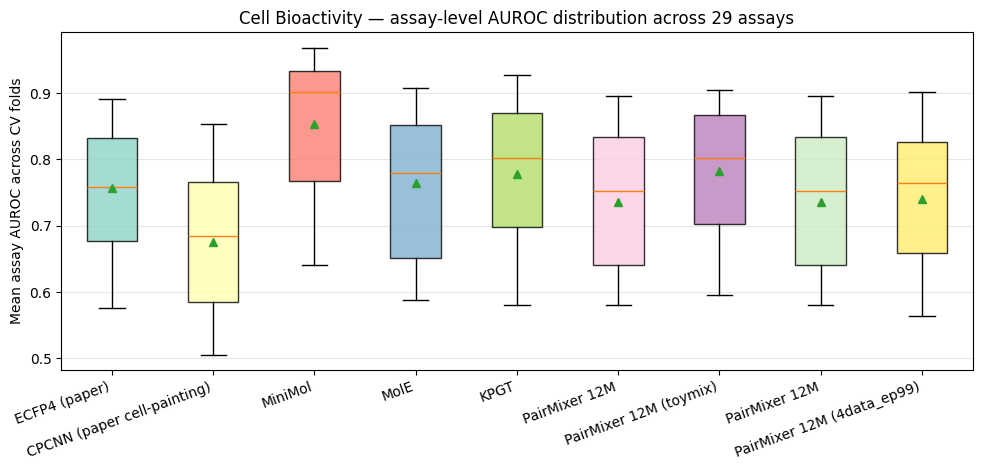

In [7]:
import sys
from pathlib import Path as _Path
_REPO_ROOT = str(_Path('..').resolve())
if _REPO_ROOT not in sys.path:
    sys.path.insert(0, _REPO_ROOT)

import matplotlib.pyplot as plt
from downstream.tasks.bioactivity.report import (
    DEFAULT_ENCODER_LABELS,
    DEFAULT_MODEL_ORDER,
    build_assay_auroc_boxplot_frame,
    build_auroc_threshold_table,
    build_enrichment_factor_table,
    build_macro_summary_table,
    build_per_assay_win_rank_table,
)

_BIO_PATH = Path('../results/downstream/bioactivity.csv')

if not _BIO_PATH.exists():
    print(f'No bioactivity results at {_BIO_PATH}. Run: bash scripts/bioactivity/run_all.sh [pairmixer_ckpt]')
else:
    _bio = pd.read_csv(_BIO_PATH)

    # Differentiate pairmixer rows by ckpt_tag so scratch and each pretrained ckpt
    # render as separate Model rows. Non-pairmixer encoders pass through unchanged.
    def _pm_enc(_row):
        if _row['encoder'] != 'pairmixer':
            return _row['encoder']
        # Prefer ckpt_path (full pretrain info) over ckpt_tag (often just 'last').
        for _src in (_row.get('ckpt_path'), _row.get('ckpt_tag')):
            if not _src:
                continue
            _s = str(_src).lower()
            if _s in ('scratch', 'random', 'none', 'nan'):
                return 'pairmixer__scratch'
            _pt = parse_pretrain_dataset(_s)
            if _pt not in ('scratch', 'unknown'):
                return f'pairmixer__{_pt}'
        return 'pairmixer__scratch'
    _bio = _bio.copy()
    _bio['encoder'] = _bio.apply(_pm_enc, axis=1)

    # Restrict PairMixer rows to: non-pretrained (scratch), toymix, and 4dset_ep99.
    _PM_KEEP = {'pairmixer__scratch', 'pairmixer__toymix', 'pairmixer__4dset_ep99'}
    _bio = _bio[
        ~_bio['encoder'].astype(str).str.startswith('pairmixer__')
        | _bio['encoder'].isin(_PM_KEEP)
    ]

    _bio_encoder_labels = dict(DEFAULT_ENCODER_LABELS)
    for _enc in _bio['encoder'].unique():
        if isinstance(_enc, str) and _enc.startswith('pairmixer__'):
            _tag = _enc[len('pairmixer__'):]
            _tag = _PAIRMIXER_PRETRAIN_RENAMES.get(_tag, _tag)
            _bio_encoder_labels[_enc] = 'PairMixer 12M' if _tag == 'scratch' else f'PairMixer 12M ({_tag})'

    # Pull every per-model metric block and merge into one (Dataset, Split, Model) frame.
    _key_cols = ['Dataset', 'Split', 'Model']
    _macro = build_macro_summary_table(_bio, encoder_labels=_bio_encoder_labels)
    _threshold = build_auroc_threshold_table(_bio, encoder_labels=_bio_encoder_labels)
    _ef = build_enrichment_factor_table(_bio)
    _win_rank = build_per_assay_win_rank_table(_bio)

    # Re-label EF / win-rank rows so PairMixer ckpt variants stay distinct.
    def _relabel(_df):
        if _df.empty:
            return _df
        _out = _df.copy()
        _out['Model'] = _out['Model'].map(lambda _m: _bio_encoder_labels.get(_m, _m))
        return _out
    _ef = _relabel(_ef)
    _win_rank = _relabel(_win_rank)

    _combined = _macro.copy()
    for _part in (_threshold, _ef, _win_rank):
        if _part.empty:
            continue
        _combined = _combined.merge(_part, on=_key_cols, how='outer')
    _combined = _combined.set_index(_key_cols)

    _metric_directions = {_c: 'higher' for _c in _combined.columns}
    if 'Avg rank' in _combined.columns:
        _metric_directions['Avg rank'] = 'lower'

    # Transpose: rows = metrics, columns = methods. The (Dataset, Split) outer
    # levels are degenerate for this table, so we drop them.
    _flat = _combined.copy()
    _flat.index = _flat.index.get_level_values('Model')
    _table = _flat.T
    _table.index.name = 'Metric'

    def _style_metric_rows(_s):
        _styles = pd.DataFrame('', index=_s.index, columns=_s.columns)
        for _metric in _s.index:
            _direction = _metric_directions.get(_metric, 'higher')
            _vals = []
            for _model in _s.columns:
                _raw = str(_s.loc[_metric, _model]).split(' ')[0]
                try:
                    _vals.append((_model, float(_raw)))
                except ValueError:
                    pass
            if len(_vals) < 2:
                continue
            _best = (max(_vals, key=lambda x: x[1])[0]
                     if _direction == 'higher'
                     else min(_vals, key=lambda x: x[1])[0])
            _styles.loc[_metric, _best] = 'font-weight: bold'
        return _styles

    display(
        _table.style
        .apply(_style_metric_rows, axis=None)
        .set_caption('Cell Bioactivity (Fredinh et al., 2024) — macro AUROC/AUPRC, assay-threshold counts, enrichment factor, per-assay wins, avg rank')
        .set_table_styles([
            {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td', 'props': [('text-align', 'center')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
        ])
    )

    # LaTeX: bold best per row in-place, single-level row index → no gray category headers.
    _latex_table = _table.copy().astype(object)
    for _metric in _latex_table.index:
        _direction = _metric_directions.get(_metric, 'higher')
        _vals = []
        for _model in _latex_table.columns:
            _raw = str(_latex_table.loc[_metric, _model]).split(' ')[0]
            try:
                _vals.append((_model, float(_raw)))
            except ValueError:
                pass
        if len(_vals) < 2:
            continue
        _best = (max(_vals, key=lambda x: x[1])[0]
                 if _direction == 'higher'
                 else min(_vals, key=lambda x: x[1])[0])
        _cur = _latex_table.loc[_metric, _best]
        _latex_table.loc[_metric, _best] = f'\\textbf{{{_cur}}}'
    print('\n% LaTeX (full breakdown — methods as columns, metrics as rows):')
    print(_to_clean_latex(
        _latex_table,
        caption='Cell Bioactivity — macro AUROC/AUPRC, assay-threshold counts, enrichment factor, per-assay wins, avg rank',
    ))

    # --- Simplified view: AUROC, AUROC ≥ 0.9, EF@1%, Assay wins, Avg rank ---
    _SIMPLE_METRICS = ['AUROC \u2191', 'AUROC \u2265 0.9', 'EF@1%', 'Assay wins', 'Avg rank']
    _simple_present = [_m for _m in _SIMPLE_METRICS if _m in _table.index]
    if _simple_present:
        _simple_table = _table.loc[_simple_present]
        display(
            _simple_table.style
            .apply(_style_metric_rows, axis=None)
            .set_caption('Cell Bioactivity — simplified (AUROC, AUROC \u2265 0.9, EF@1%, Assay wins, Avg rank)')
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
                {'selector': 'td', 'props': [('text-align', 'center')]},
                {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
            ])
        )
        _simple_latex = _simple_table.copy().astype(object)
        for _metric in _simple_latex.index:
            _direction = _metric_directions.get(_metric, 'higher')
            _vals = []
            for _model in _simple_latex.columns:
                _raw = str(_simple_latex.loc[_metric, _model]).split(' ')[0]
                try:
                    _vals.append((_model, float(_raw)))
                except ValueError:
                    pass
            if len(_vals) < 2:
                continue
            _best = (max(_vals, key=lambda x: x[1])[0]
                     if _direction == 'higher'
                     else min(_vals, key=lambda x: x[1])[0])
            _cur = _simple_latex.loc[_metric, _best]
            _simple_latex.loc[_metric, _best] = f'\\textbf{{{_cur}}}'
        print('\n% LaTeX (simplified — selected metrics only):')
        print(_to_clean_latex(
            _simple_latex,
            caption='Cell Bioactivity — selected metrics (AUROC, AUROC $\\geq$ 0.9, EF@1%, Assay wins, Avg rank)',
        ))

    # Assay-level AUROC distribution boxplot.
    _box_df = build_assay_auroc_boxplot_frame(_bio)
    if _box_df.empty:
        print('No per-assay AUROC columns found for the assay-level boxplot.')
    else:
        _split = 'cv6'
        _box_df = _box_df[_box_df['Split'] == _split].copy()
        _box_df['Model'] = _box_df['Model'].map(lambda _m: _bio_encoder_labels.get(_m, _m))
        _order = [m for m in _bio_encoder_labels.values() if m in set(_box_df['Model'])]
        _order += sorted(set(_box_df['Model']) - set(_order))
        _box_data = [
            _box_df.loc[_box_df['Model'] == _model, 'AUROC'].to_numpy()
            for _model in _order
        ]
        plt.figure(figsize=(10, 4.8))
        _box = plt.boxplot(_box_data, tick_labels=_order, patch_artist=True, showmeans=True)
        _colors = plt.cm.Set3(np.linspace(0, 1, len(_order)))
        for _patch, _color in zip(_box['boxes'], _colors):
            _patch.set_facecolor(_color)
            _patch.set_alpha(0.8)
        plt.ylabel('Mean assay AUROC across CV folds')
        plt.title('Cell Bioactivity — assay-level AUROC distribution across 29 assays')
        plt.xticks(rotation=20, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
